# Analyzing the Impact of Air Quality and Weather on Daily Bike Rentals

**DAP Mini Project**

**Author:** Anushka 
**Date:** 11 november

---

This notebook walks through data loading, cleaning, EDA, hypothesis testing, and regression modeling for predicting daily bike rentals using weather and air-quality features.


## Setup and Dataset

This notebook is designed to run in a local **Jupyter Notebook** environment.

**Dataset**: `SeoulBikeData.csv` (common versions available on Kaggle / UCI / GitHub). The notebook will attempt to download a publicly available copy — if automatic download fails, please place `SeoulBikeData.csv` into the same folder as this notebook.


In [1]:
# Common imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 120)


In [2]:
# Attempt to download a copy from a public raw URL (may fail if unavailable).
# If this fails, please manually download/upload 'SeoulBikeData.csv' to this notebook's folder.
csv_path = Path('SeoulBikeData.csv')

if not csv_path.exists():
    try:
        import urllib.request
        url = 'https://raw.githubusercontent.com/selva86/datasets/master/SeoulBikeData.csv'  # common mirror; may or may not be available
        print('Attempting to download dataset from:', url)
        urllib.request.urlretrieve(url, csv_path)
        print('Download complete.')
    except Exception as e:
        print('Automatic download failed:', e)
        print('Please download the dataset manually and save as "SeoulBikeData.csv" in this folder.')
else:
    print('SeoulBikeData.csv found in the working directory.')

SeoulBikeData.csv found in the working directory.


In [3]:
# Load dataset
try:
    df = pd.read_csv('SeoulBikeData.csv', encoding='unicode_escape')
    print('Loaded dataset with shape:', df.shape)
    display(df.head())
except Exception as e:
    print('Failed to load dataset. Make sure SeoulBikeData.csv is in the notebook folder.')
    raise e

Loaded dataset with shape: (8760, 14)


,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


## Step 1 — Dataset overview

- Inspect basic info, columns, and datatypes.  
- Briefly describe the features (numerical / categorical / date).

In [4]:
# Basic dataset overview
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

In [5]:
# Display summary statistics for numeric columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Rented Bike Count,8760.0,704.602055,644.997468,0.0,191.00,504.50,1065.25,3556.00
Hour,8760.0,11.500000,6.922582,0.0,5.75,11.50,17.25,23.00
Temperature(°C),8760.0,12.882922,11.944825,-17.8,3.50,13.70,22.50,39.40
Humidity(%),8760.0,58.226256,20.362413,0.0,42.00,57.00,74.00,98.00
Wind speed (m/s),8760.0,1.724909,1.036300,0.0,0.90,1.50,2.30,7.40
Visibility (10m),8760.0,1436.825799,608.298712,27.0,940.00,1698.00,2000.00,2000.00
Dew point temperature(°C),8760.0,4.073813,13.060369,-30.6,-4.70,5.10,14.80,27.20
Solar Radiation (MJ/m2),8760.0,0.569111,0.868746,0.0,0.00,0.01,0.93,3.52
Rainfall(mm),8760.0,0.148687,1.128193,0.0,0.00,0.00,0.00,35.00
Snowfall (cm),8760.0,0.075068,0.436746,0.0,0.00,0.00,0.00,8.80


In [6]:
# Check for missing values and duplicates
print('Missing values per column:')
display(df.isnull().sum())
print('\nNumber of duplicate rows:', df.duplicated().sum())


Missing values per column:


Date                         0
Rented Bike Count            0
Hour                         0
Temperature(°C)              0
Humidity(%)                  0
Wind speed (m/s)             0
Visibility (10m)             0
Dew point temperature(°C)    0
Solar Radiation (MJ/m2)      0
Rainfall(mm)                 0
Snowfall (cm)                0
Seasons                      0
Holiday                      0
Functioning Day              0
dtype: int64


Number of duplicate rows: 0


## Step 2 — Data Cleaning & Preparation

- Convert date column to `datetime`.
- Handle missing values, duplicates, and outliers.
- Encode categorical variables (Seasons / Holiday / Functioning Day).


In [7]:
# Example preprocessing steps (adjust column names if needed)
df_clean = df.copy()

# Convert Date column (common column name: 'Date')
if 'Date' in df_clean.columns:
    df_clean['Date'] = pd.to_datetime(df_clean['Date'], dayfirst=True, errors='coerce')

# Remove exact duplicates
df_clean.drop_duplicates(inplace=True)

# Example: rename columns to simpler names if the dataset uses long names
df_clean.columns = [c.strip().replace(' ', '_').replace('(', '').replace(')', '') for c in df_clean.columns]

# Show cleaned head
df_clean.head()

,Date,Rented_Bike_Count,Hour,Temperature°C,Humidity%,Wind_speed_m/s,Visibility_10m,Dew_point_temperature°C,Solar_Radiation_MJ/m2,Rainfallmm,Snowfall_cm,Seasons,Holiday,Functioning_Day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [8]:
# Handling missing values (example strategies)
missing = df_clean.isnull().sum()
missing[missing>0]

Series([], dtype: int64)

In [9]:
# Simple imputation: numeric -> median, categorical -> mode (customize as needed)
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object','category']).columns.tolist()

for c in num_cols:
    if df_clean[c].isnull().any():
        df_clean[c].fillna(df_clean[c].median(), inplace=True)

for c in cat_cols:
    if df_clean[c].isnull().any():
        df_clean[c].fillna(df_clean[c].mode().iloc[0], inplace=True)

print('Missing values after imputation:')
display(df_clean.isnull().sum()[df_clean.isnull().sum()>0])

Missing values after imputation:


Series([], dtype: int64)

In [10]:
# Encode categorical variables (Seasons, Holiday, Functioning Day are common)
for col in ['Seasons','Holiday','Functioning_Day']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')

# One-hot encode categorical columns if present
df_model = pd.get_dummies(df_clean, drop_first=True)
print('Shape after encoding:', df_model.shape)

Shape after encoding: (8760, 16)


### Outlier handling (IQR method example)

In [11]:
# Remove outliers from target 'Rented_Bike_Count' if it exists
target_col = None
for name in df_model.columns:
    if 'Rented' in name or 'Rented_Bike_Count' in name:
        target_col = name
        break

# Try common names if not found
if target_col is None:
    if 'Rented_Bike_Count' in df_model.columns:
        target_col = 'Rented_Bike_Count'
    elif 'Rented_Bike_Count' in df_clean.columns:
        target_col = 'Rented_Bike_Count'
    elif 'Rented Bike Count' in df_clean.columns:
        target_col = 'Rented Bike Count'

print('Detected target column:', target_col)

Detected target column: Rented_Bike_Count


In [12]:
# Apply IQR outlier removal only if target found
if target_col and target_col in df_model.columns:
    q1 = df_model[target_col].quantile(0.25)
    q3 = df_model[target_col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5*iqr
    high = q3 + 1.5*iqr
    before = df_model.shape[0]
    df_model = df_model[(df_model[target_col] >= low) & (df_model[target_col] <= high)]
    after = df_model.shape[0]
    print(f'Removed {before-after} outlier rows from {target_col} using IQR.')

Removed 158 outlier rows from Rented_Bike_Count using IQR.


## Step 3 — Exploratory Data Analysis (EDA)

Visualize distributions, relationships, and correlations.

<Figure size 1200x800 with 0 Axes>

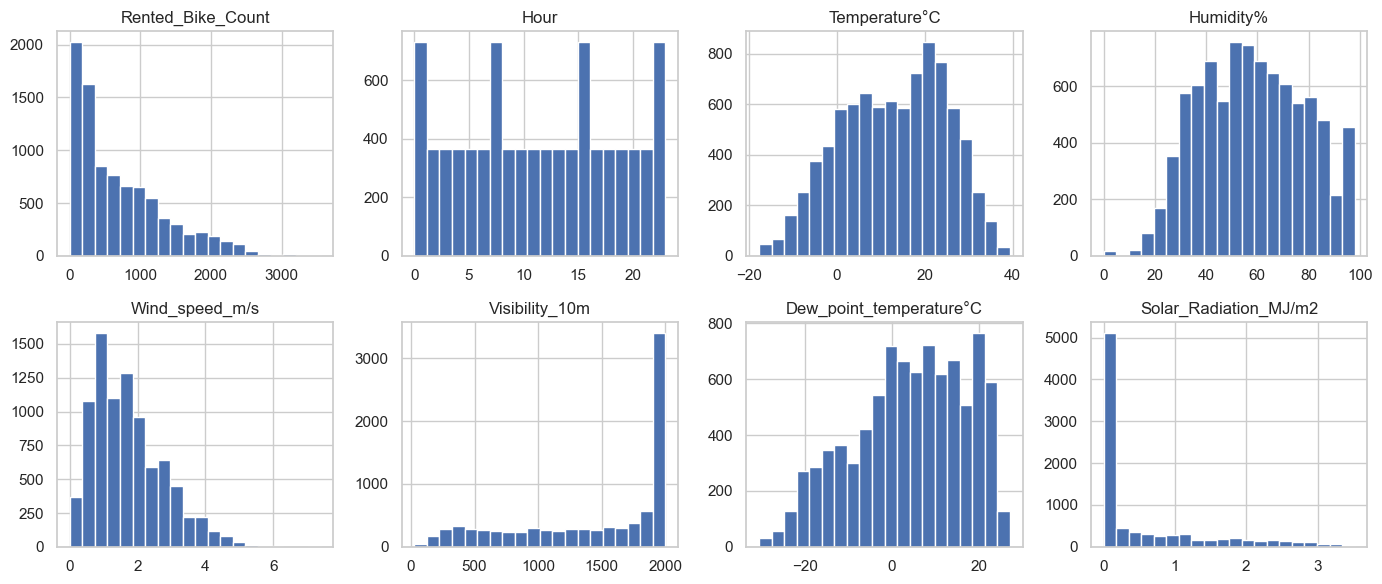

In [13]:
# Histograms for numeric features
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
num_cols_small = num_cols[:8]  # plot first few to keep output manageable
plt.figure(figsize=(12,8))
df_clean[num_cols_small].hist(bins=20, layout=(2,4), figsize=(14,6))
plt.tight_layout()

Text(0.5, 1.0, 'Correlation Matrix')

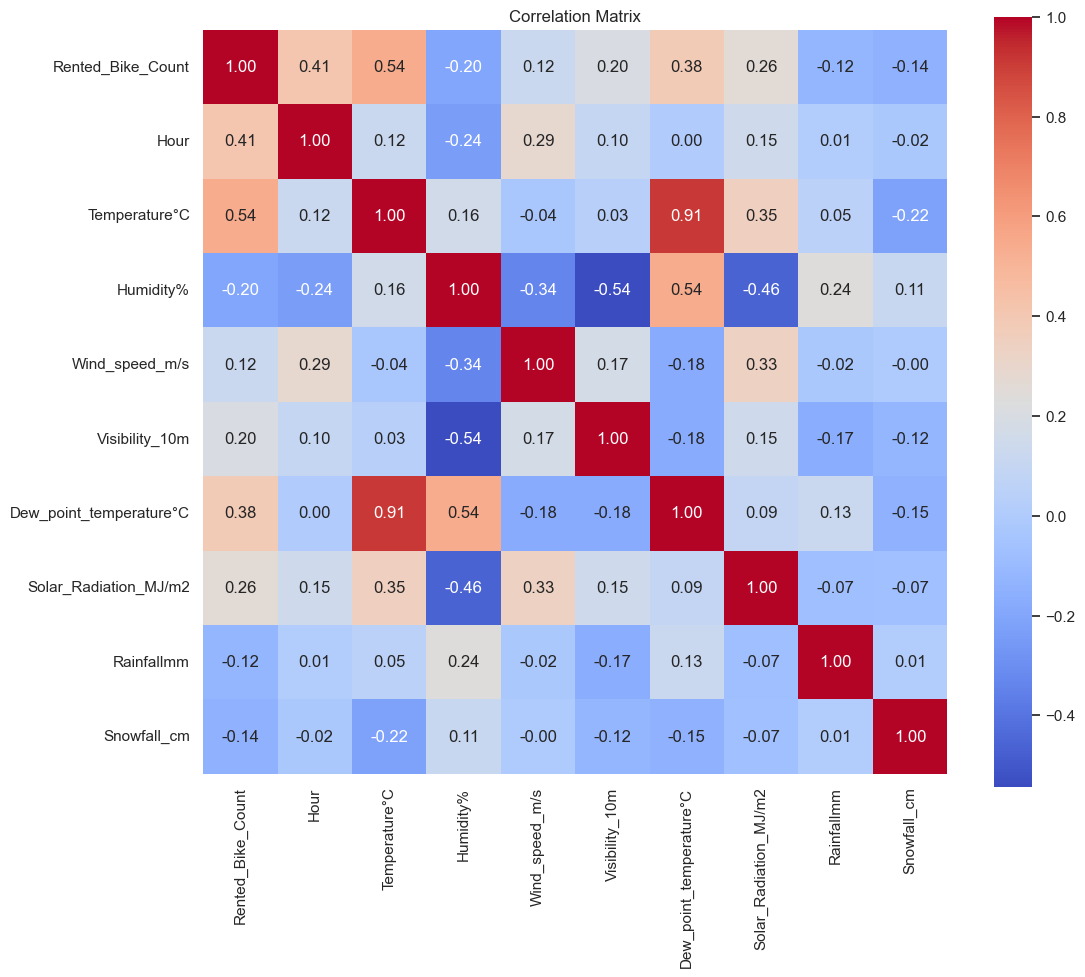

In [14]:
# Correlation heatmap (numeric features)
plt.figure(figsize=(12,10))
corr = df_clean.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix')

In [15]:
# Pairplot for a few relevant features if the dataset has them
pairs = ['Rented_Bike_Count','Temperature','Humidity','PM2.5']  # common column names
pairs_present = [p for p in pairs if p in df_clean.columns]
if len(pairs_present) > 1:
    sns.pairplot(df_clean[pairs_present].sample(min(1000, df_clean.shape[0])), diag_kind='kde', corner=True)
else:
    print('Not enough typical columns found for pairplot. Columns present:', df_clean.columns.tolist()[:20])

Not enough typical columns found for pairplot. Columns present: ['Date', 'Rented_Bike_Count', 'Hour', 'Temperature°C', 'Humidity%', 'Wind_speed_m/s', 'Visibility_10m', 'Dew_point_temperature°C', 'Solar_Radiation_MJ/m2', 'Rainfallmm', 'Snowfall_cm', 'Seasons', 'Holiday', 'Functioning_Day']


## Step 4 — Statistical Analysis & Hypothesis Testing

Example: test whether functioning days have different mean rentals vs non-functioning days.

In [16]:
from scipy.stats import ttest_ind

# Attempt to use a functioning day column
func_col = None
for c in df_clean.columns:
    if 'Functioning' in c:
        func_col = c
        break

if func_col and 'Rented_Bike_Count' in df_clean.columns:
    group1 = df_clean[df_clean[func_col]==1]['Rented_Bike_Count']
    group0 = df_clean[df_clean[func_col]==0]['Rented_Bike_Count']
    tstat, pval = ttest_ind(group1, group0, equal_var=False)
    print('Functioning day column:', func_col)
    print('t-statistic:', tstat, 'p-value:', pval)
else:
    print('Required columns for this test not found. Please adapt the test to your dataset columns.')

Functioning day column: Functioning_Day
t-statistic: nan p-value: nan


## Step 5 — Modeling (Multiple Linear Regression)

We will build a regression model to predict daily rentals using selected numeric features.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Identify a reasonable target and numeric predictors
possible_targets = [c for c in df_clean.columns if 'Rented' in c or 'Rent' in c or 'Rental' in c]
print('Possible targets detected:', possible_targets)

if possible_targets:
    y_col = possible_targets[0]
else:
    raise ValueError('No obvious target found. Please set y_col to the correct rental count column.')

# Choose numeric predictors (drop target)
X = df_clean.select_dtypes(include=[np.number]).drop(columns=[y_col], errors='ignore')
y = df_clean[y_col]

# If any datetime features exist, optionally extract useful columns
if 'Date' in df_clean.columns:
    X['month'] = df_clean['Date'].dt.month
    X['dayofweek'] = df_clean['Date'].dt.dayofweek
    X['day'] = df_clean['Date'].dt.day

# Align shapes if earlier one-hot created df_model; prefer df_clean here
X = X.fillna(0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('R2:', r2_score(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('RMSE:', mean_squared_error(y_test, y_pred, squared=False))

Possible targets detected: ['Rented_Bike_Count']
R2: 0.466972750083944
MAE: 348.8269957563022
RMSE: 471.2576771508342


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [18]:
# Show coefficients for interpretation (top predictors by absolute coef)
coefs = pd.Series(model.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)
display(coefs.head(10))

Solar_Radiation_MJ/m2     -78.632793
Rainfallmm                -60.842523
Hour                       28.124356
Temperature°C              27.226177
Snowfall_cm                10.211657
Wind_speed_m/s              9.531386
dayofweek                  -8.766255
Humidity%                  -8.319875
month                       8.219160
Dew_point_temperature°C     3.873184
dtype: float64

## Step 6 — Interpretation & Inference

Summarize the major findings here: highlight which features are influential, what hypothesis tests showed, and how well the model performed.

## Step 7 — Visualizations for Reporting

Include final polished plots and captions. For example:
- Scatter plot: Temperature vs Rentals
- Line plot: PM2.5 vs Rentals (binned)


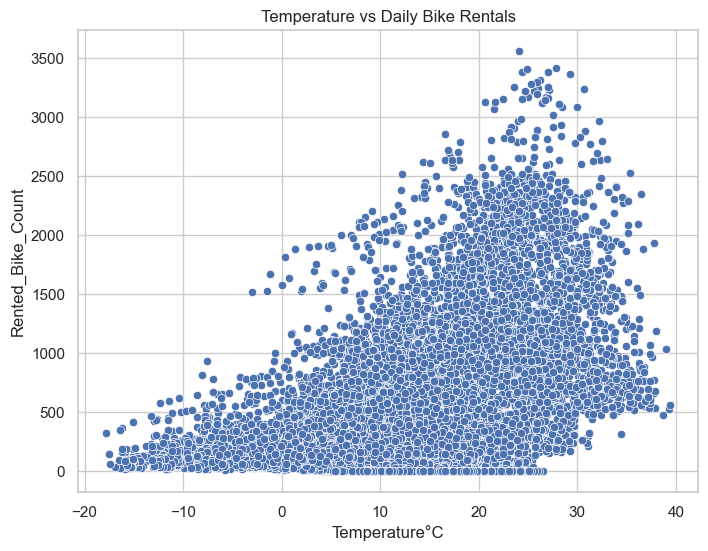

In [19]:
# Example visualization: Temperature vs Rentals (if columns exist)
temp_col = None
for c in df_clean.columns:
    if 'Temp' in c or 'Temperature' in c:
        temp_col = c
        break

if temp_col and y_col in df_clean.columns:
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=df_clean[temp_col], y=df_clean[y_col])
    plt.title('Temperature vs Daily Bike Rentals')
    plt.xlabel(temp_col)
    plt.ylabel(y_col)
    plt.show()
else:
    print('Temperature or target column not found for this plot. Columns available:', df_clean.columns[:20])

## Step 8 — Conclusion

Write a short final paragraph connecting data patterns, hypothesis test results, and model performance. Mention limitations and future work (more features, hourly granularity, advanced models).

----

### How to use this notebook
1. Run cells in order.  
2. If automatic download fails, manually place `SeoulBikeData.csv` in the same folder and re-run the load cell.  
3. Adapt column names if your dataset variant uses different names (e.g., `Rented Bike Count` vs `Rented_Bike_Count`).